## Convocatoria 1 - Proyecto 1
Autor: Oscar soria Corral

#### 0) Cargar una de las imágenes histológicas

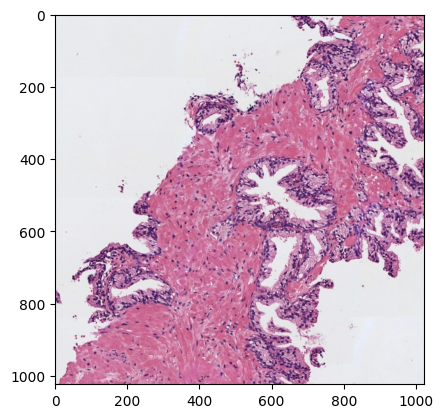

In [3]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
from skimage import io
img = io.imread('histo_1.jpg')
rgb = img.copy()

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
rgb_p = rgb.astype('uint8')/255

# Visualizar la imagen
import matplotlib.pyplot as plt
plt.imshow(rgb_p)

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

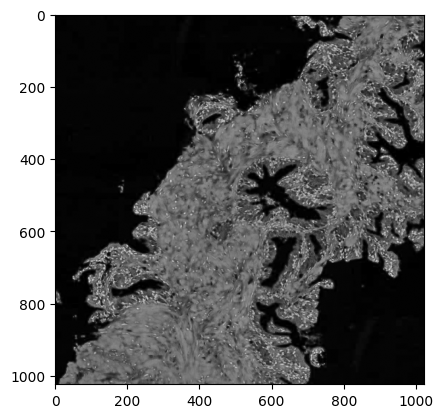

In [4]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
import numpy as np
import cv2
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    C = (1-rgb_p[:,:,0]-K)/(1-K)
    M = (1-rgb_p[:,:,1]-K)/(1-K)
    Y = (1-rgb_p[:,:,2]-K)/(1-K)

CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
C,M,Y,K = cv2.split(CMYK)

# Visualizar la imagen del canal magenta
plt.imshow(M.astype('uint8'), cmap='gray')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

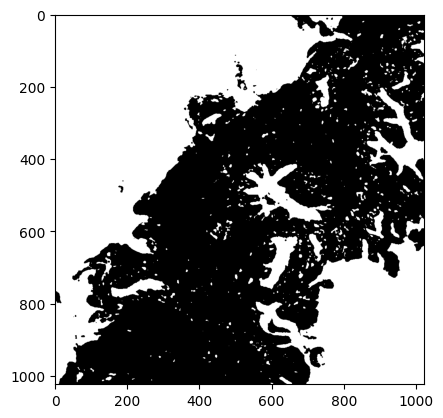

In [5]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
img_gaus = cv2.GaussianBlur(M.astype('uint8'), (5,5), 0)
_, mask = cv2.threshold(img_gaus,0,1,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Visualizar la máscara resultante
plt.imshow(mask, cmap='gray')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

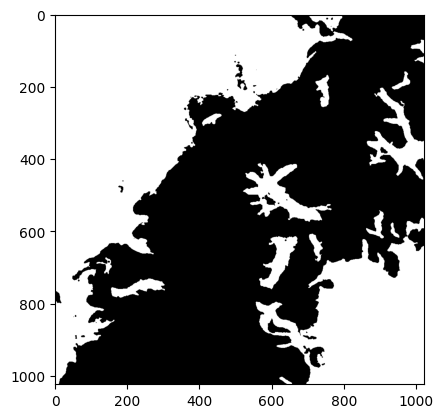

In [6]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
import skimage.morphology as morph
mask_filtered = morph.remove_small_objects(mask.astype(bool), min_size=300)
mask_filtered = mask_filtered.astype('uint8')

# Visualizaer la máscara resultante
plt.imshow(mask_filtered, cmap='gray')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [7]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante.

#### 5) Rellenar los objetos de los lúmenes

In [8]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [9]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles.
# Visualizar la imagen superpuesta

#### 7) Identificar y cropear el lumen más grande

In [10]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado

In [11]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad